In [32]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import os
import sys
import pandas as pd

current_dir = os.getcwd()

project_root = os.path.abspath(os.path.join(current_dir, "..", ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

print(f"✅ Project root added: {project_root}")

try:
    from olist.order import Order
    orders = Order().get_training_data()
    print(f"🚀 Success! Training data loaded with {len(orders)} rows.")
except ModuleNotFoundError:
    print("❌ Still can't find the 'olist' package. Check your folder structure!")

✅ Project root added: /Users/ilos/code/inurekici.sc/projects/S14D3Ps--olist-analysis
🚀 Success! Training data loaded with 96353 rows.


# Satıcılar

🎯 Amacımız, diğerlerine göre tekrarlı olarak düşük performans gösteren satıcıları bulmak ve nedenini anlamaktır.  
Bu, Olist'in gelecekte kâr marjını artırmaya yönelik önerilerimizi şekillendirmemize yardımcı olacaktır.

## 1 - `olist/seller.py`  

`order.py` ile benzer bir süreçte, size `olist/seller.py` modülünü sunduk; içinde `Seller` sınıfı ve `Seller().get_training_data` yöntemi bulunuyor. Bu yöntem aşağıdaki özellikleri içeren bir DataFrame döndürür:

| feature_name | type | açıklama |
| --- | --- | --- |
| `seller_id` | str | satıcının benzersiz kimliği (UNIQUE) |
| `seller_city` | str | satıcının bulunduğu şehir |
| `seller_state` | str | satıcının bulunduğu eyalet |
| `delay_to_carrier` | float | sipariş, `shipping_limit_date`'den önce teslim edildiyse 0 döner; aksi takdirde gecikme süresini verir |
| `wait_time` | float | satıcı başına ortalama teslimat süresi (bekleme süresi) |
| `date_first_sale` | datetime | Olist üzerinde yapılan ilk satışın tarihi |
| `date_last_sale` | datetime | Olist üzerindeki son satışın tarihi |
| `months_on_olist` | float | Olist'te geçirilen yaklaşık ay sayısı |
| `share_of_five_stars` | float | satıcının yer aldığı siparişlerdeki beş yıldız değerlendirmelerinin oranı |
| `share_of_one_stars` | float | satıcının yer aldığı siparişlerdeki bir yıldız değerlendirmelerinin oranı |
| `review_score` | float | satıcının yer aldığı siparişler için ortalama değerlendirme puanı |
| `n_orders` | int | satıcının yer aldığı benzersiz sipariş sayısı |
| `quantity` | int | bu satıcı tarafından satılan toplam ürün adedi |
| `quantity_per_order` | float | bu satıcı için sipariş başına ortalama ürün sayısı |
| `sales` | float | bu satıcı ile ilişkili toplam satış tutarı (kargo hariç), BRL cinsinden |

❓ **Aşağıya yeni sınıfınızı import edin ve eğitim veri çerçevenizi inceleyin!** Kodları incelemek için zaman ayırın ve sizin için tam olarak nelerin hesaplandığını anlayın.

In [34]:
from olist.seller import Seller

seller = Seller()

sellers = seller.get_training_data()

sellers.head()

,seller_id,seller_city,seller_state,delay_to_carrier,wait_time,date_first_sale,date_last_sale,months_on_olist,n_orders,quantity,quantity_per_order,sales,review_score,share_of_one_stars,share_of_five_stars
0,3442f8959a84dea7ee197c632cb2df15,campinas,SP,0.000000,13.018588,2017-05-05 16:25:11,2017-08-30 12:50:19,4.0,3,3,1.000,218.70,3.000000,0.333333,0.333333
1,d1b65fc7debc3361ea86b5f14c68d2e2,mogi guacu,SP,0.000000,9.065716,2017-03-29 02:10:34,2018-06-06 20:15:21,14.0,40,41,1.025,11703.07,4.560976,0.048780,0.731707
2,ce3ad9de960102d0677a81f5d0bb7b2d,rio de janeiro,RJ,0.000000,4.042292,2018-07-30 12:44:49,2018-07-30 12:44:49,0.0,1,1,1.000,158.00,5.000000,0.000000,1.000000
3,c0f3eea2e14555b6faeea3dd58c1b1c3,sao paulo,SP,0.000000,5.667187,2018-08-03 00:44:08,2018-08-03 00:44:08,0.0,1,1,1.000,79.99,5.000000,0.000000,1.000000
4,51a04a8a6bdcb23deccc82b0b80742cf,braganca paulista,SP,3.353727,35.314861,2017-11-14 12:15:25,2017-11-14 12:15:25,0.0,1,1,1.000,167.99,1.000000,1.000000,0.000000


🤔 Her satıcı için henüz hesaplanması gereken bir şey kaldı:
- Aşırı yüksek değerlendirmelerin oranı (`share_of_five_stars`) ve aşırı düşük değerlendirmelerin oranı (`share_of_one_stars`)
- (ortalama) `review_score`

😱 Düşük puanlı her sipariş Olist'in itibarına olumsuz etki yapar; bu etki `cost_of_review` ile modellenir.

Bu, daha sonra her satıcı için toplam `cost_of_review`'u hesaplamamıza yardımcı olacak!

❓ **Sizin doldurmanız gereken son metod: `get_review_score()`'u implemente edin.**

In [35]:
def get_review_score(self):
        """
        Returns a DataFrame with:
        'seller_id', 'share_of_five_stars', 'share_of_one_stars', 'review_score'

        Example:
            >>> seller = Seller()
            >>> df = seller.get_review_score()
            >>> df.columns.contains('review_score')
            True
        """
        orders_reviews = self.data['order_reviews'].copy()
        order_items = self.data['order_items'].copy()

        matching_table = order_items.merge(orders_reviews, on='order_id')

        matching_table['is_one_star'] = matching_table['review_score'].apply(lambda x: 1 if x == 1 else 0)
        matching_table['is_five_star'] = matching_table['review_score'].apply(lambda x: 1 if x == 5 else 0)

        res = matching_table.groupby('seller_id').agg({
            'review_score': 'mean',
            'is_one_star': 'mean',
            'is_five_star': 'mean'
        }).reset_index()

        res.columns = ['seller_id', 'review_score', 'share_of_one_stars', 'share_of_five_stars']

        return res

🧪 Kodunuzu aşağıda test edin

In [36]:
from nbresult import ChallengeResult

tmp = Seller().get_training_data()
result = ChallengeResult('seller',
    shape = tmp.shape,
    median = tmp.review_score.median(),
    columns = tmp.columns
)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/ilos/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/ilos/code/inurekici.sc/projects/S14D3Ps--olist-analysis/02-Regression-Models/data-sellers/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 3 items

test_seller.py::TestSeller::test_column_names PASSED                     [ 33%]
test_seller.py::TestSeller::test_median_review_score PASSED              [ 66%]
test_seller.py::TestSeller::test_shape PASSED                            [100%]

============================== 3 passed in 0.50s ===============================


💯 You can commit your code:

git add tests/seller.pickle

git commit -m 'Completed seller step'

git push origin master



💡 **Tam satır sayısını elde edemiyor musunuz?**
<details><summary>Fazladan 3 satır mı var?</summary>
Left veya right join mi yaptınız? Nedenini anlıyoruz; fakat burada sadece değerlendirme alan satıcılarla ilgileniyoruz; bu yüzden inner join kullandık.
</details>
<details><summary>2 satır mı eksik?</summary>
`Orders().get_training_data()`'ı mı kullandınız? Bu geçerli bir seçenek, fakat sadece değerlendirmelerle ilgileniyorsak biraz aşırı olabilir. O method birçok hesaplama yapar ve döndürdüğü sütunların çoğuna ihtiyaç duymuyoruz. İhtiyacımıza daha uygun başka bir `Order` methodu bulun.
</details>

⚠️ `olist` reposundaki `seller.py` dosyasına yaptığınız kod değişikliklerini commit etmeyi unutmayın!

## 2 - Satıcıları İnceleme

### (2.1) Görselleştirmeler

Bu satıcılar hakkında ilk ***`EDA - Keşifsel Veri Analizi`*** ile başlayalım.

👉 `sellers` için özet istatistiklere bakın. Satıcı başına siparişlerin medyanı nedir ❓

In [37]:
median_orders = sellers['n_orders'].median()
print(f"The median number of orders per seller is: {median_orders}")

The median number of orders per seller is: 7.0


👉 Bir sonraki adımda, veri setindeki her sayısal değişkenin dağılımını tek bir büyük görselde çizeceğiz. 

Kod size verildi, hücreyi çalıştırmanız yeterli.

- 👀 Herhangi bir aykırı değer fark ediyor musunuz?
- Sipariş sayısının dağılımı nasıl görünüyor ❓

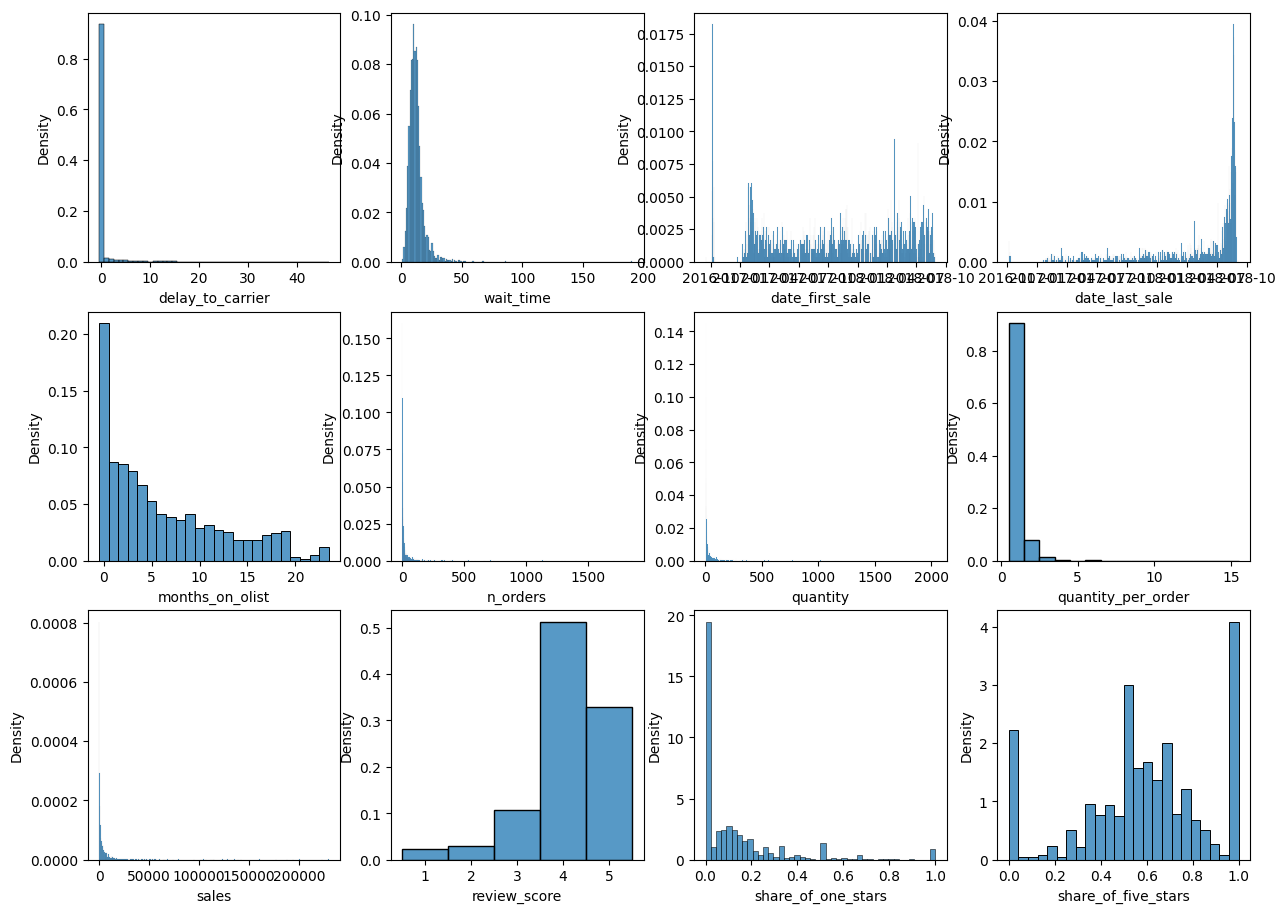

In [38]:
plt.figure(figsize=(15,11))
for (i, col) in enumerate(sellers.describe().columns):#["wait_time", "delay_to_carrier", "avg_review_score", "n_orders", "quantity", "price"]):
    plt.subplot(3,4,i+1)
    sns.histplot(sellers[col], kde=False, stat='density', discrete=[True,None][col in ['share_of_one_stars','share_of_five_stars','sales']]);

💡 Çok düşük değerlendirme puanlarına sahip bir grup satıcının öne çıktığı görünüyor!

📊 Grafiksel olarak inceleyelim:
- `plotly` kullanarak `delay_to_carrier` ile `wait_time` arasındaki ilişkiyi gösteren bir saçılma grafiği (scatterplot) oluşturuyoruz; kabarcık boyutunu satıcının toplam `sales`'i, rengini ise `review_score` belirliyor.

`plotly`'ı daha sonra detaylı göreceğiz; şimdilik aşağıdaki hücreyi çalıştırın.

In [39]:
import plotly.express as px
fig = px.scatter(data_frame = sellers[sellers['review_score'] < 4],
    x="wait_time",
    y="delay_to_carrier",
    size="sales",
    color="review_score",
    size_max = 60,
    opacity = 0.5
)
fig.show()

In [40]:
worst_sellers = sellers[sellers['share_of_one_stars'] > 0.1]

fig = px.scatter(
    data_frame=worst_sellers,
    x="wait_time",
    y="delay_to_carrier",
    size="sales",
    color="review_score",
    size_max=60,
    opacity=0.5,
    title="Analysis of Sellers with High 1-Star Rates"
)

fig.update_xaxes(range=[20, 100])
fig.show()

En kötü satıcıları bulmak için `x`, `y`, `color` ve `size` değerlerini değiştirmekten çekinmeyin.

### (2.2) `review_score`'u OLS ile modelleme

⚠️ Saçılma grafikleri veriyi görsel olarak analiz etmemizi sağlar, fakat sınırlamaları vardır: deneme-yanılma içerir ve ilişkileri yalnızca niteliksel değerlendiririz.

💡 **Satıcıların `review_score`** değişkenini açıklamak için daha sağlam bir yöntem, `statsmodels` içinde **çok değişkenli (multivariate) OLS** kullanarak çeşitli özelliklerin `review_score` üzerindeki etkisini modellemektir.

İstediğiniz sayısal özellikleri kullanarak bir OLS oluşturalım.

👉 Regresyon katsayılarını karşılaştırabilmek için önce aşağıdaki `standardize` fonksiyonunu kullanarak özelliklerinizi standardize edin.

In [41]:
def standardize(df, features):
    """Standardize specified numerical features in a DataFrame using z-score.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    features : list of str
        List of column names to standardize.

    Returns
    -------
    pandas.DataFrame
        A copy of the original dataframe where the specified features have been
        standardized to zero mean and unit variance. Other columns are left
        unchanged.
    """
    df_standardized = df.copy()
    mu = df[features].mean()
    sigma = df[features].std()
    df_standardized[features] = (df[features] - mu) / sigma
    return df_standardized

In [ ]:
features = [
    'wait_time',
    'delay_to_carrier',
    'n_orders',
    'quantity',
    'quantity_per_order',
    'sales'
]
sellers_standardized = standardize(sellers, features)

👉 Sonraki adımda bir OLS modeli oluşturun ve fit edin.

In [51]:
model = smf.ols(formula=f"review_score ~ {'+ '.join(features)}", data=sellers_standardized).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     113.4
Date:                Fri, 02 Jan 2026   Prob (F-statistic):          4.42e-129
Time:                        08:14:53   Log-Likelihood:                -3329.4
No. Observations:                2967   AIC:                             6673.
Df Residuals:                    2960   BIC:                             6715.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.0749      0

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df, feature_list):
    """
    Calculates Variance Inflation Factor (VIF) for a given list of features.

    Example:
        >>> features = ['wait_time', 'delay_to_carrier', 'n_orders', 'sales']
        >>> vif_df = calculate_vif(sellers_standardized, features)
        >>> print(vif_df)
    """
    X = df[feature_list]

    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns

    vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                       for i in range(len(X.columns))]

    return vif_data.sort_values(by="VIF", ascending=False)

features = ['wait_time', 'delay_to_carrier', 'n_orders', 'quantity', 'quantity_per_order', 'sales']
print(calculate_vif(sellers_standardized, features))

              feature        VIF
2            n_orders  79.817238
3            quantity  78.559231
5               sales   2.774957
1    delay_to_carrier   1.282707
0           wait_time   1.282140
4  quantity_per_order   1.028736


In [ ]:
clean_features = [
    'wait_time',
    'delay_to_carrier',
    'n_orders',
    'quantity_per_order',
    'sales'
]

model_clean = smf.ols(
    formula=f"review_score ~ {' + '.join(clean_features)}",
    data=sellers_standardized
).fit()

print(model_clean.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     135.4
Date:                Fri, 02 Jan 2026   Prob (F-statistic):          1.45e-129
Time:                        08:18:24   Log-Likelihood:                -3330.8
No. Observations:                2967   AIC:                             6674.
Df Residuals:                    2961   BIC:                             6710.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.0749      0

❓ En etkili özellikler hangileri?

👉 Sıralanmış katsayılarla bir 📊 `bar_plot` çizin.

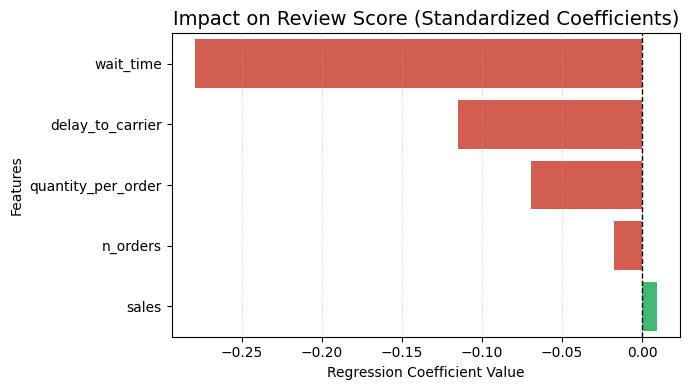

In [ ]:
coefficients = model_clean.params.drop('Intercept').sort_values()

plt.figure(figsize=(7, 4))

colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in coefficients.values]

sns.barplot(
    x=coefficients.values,
    y=coefficients.index,
    hue=coefficients.index,
    palette=colors,
    legend=False
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Impact on Review Score (Standardized Coefficients)', fontsize=14)
plt.xlabel('Regression Coefficient Value')
plt.ylabel('Features')
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

👉 Son olarak modelinizin performansını (`R-squared`) ve `residuals`'ı inceleyin

In [59]:
print(f"Model R-squared: {model_clean.rsquared:.4f}")

residuals = model_clean.resid

Model R-squared: 0.1861


👉 Gerçek değerlendirme puanlarını ve modelin tahmin ettiği puanları aynı grafikte göstererek karşılaştırın.

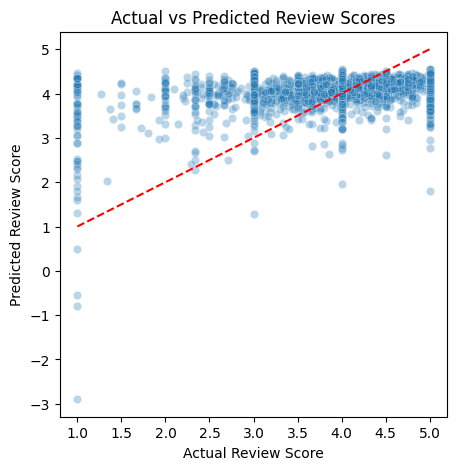

In [61]:
predicted_scores = model_clean.predict()

plt.figure(figsize=(5, 5))
sns.scatterplot(x=sellers_standardized['review_score'], y=predicted_scores, alpha=0.3)
plt.plot([1, 5], [1, 5], color='red', linestyle='--')
plt.title('Actual vs Predicted Review Scores')
plt.xlabel('Actual Review Score')
plt.ylabel('Predicted Review Score')
plt.show()

👉 Artıkları (residuals) görselleştirin

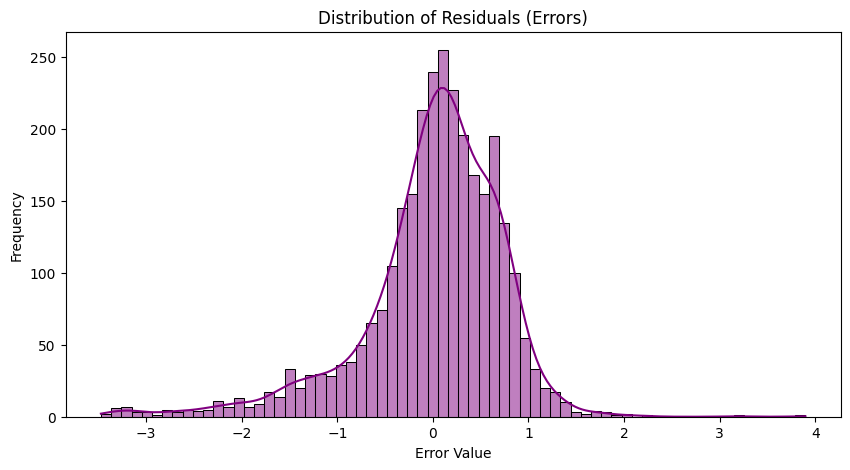

In [60]:
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Error Value')
plt.ylabel('Frequency')
plt.show()

### (2.3) Analize `seller_state` bilgisini ekleyin

❓ Henüz `seller_state` bilgisini kullanmadık.  
- Sadece `seller_state`'lere karşı `review_score`'u regresyonla modelleyen yeni bir OLS oluşturun.
- `olist/utils.py` içinde sizin için yazılmış olan `return_significative_coef(model)` fonksiyonunu kullanarak anlamlı (significant) özellikleri analiz edin.
- `review_score` açısından en iyi eyaletler hangileri?

<details>
    <summary>- İpuçları -</summary>
        
⚠️ Dikkat, `seller_state` kategorik bir özelliktir. 
    
💡 Formülde kategorik değişkenleri belirtmek için `C(a_cat_feature)` kullanın. Bu, her benzersiz kategori için bir boolean değişken (`is_cat_feature_xx`) oluşturacaktır.

</details>

In [62]:
from olist.utils import return_significative_coef

model_state = smf.ols(formula='review_score ~ seller_state', data=sellers).fit()

significant_states = return_significative_coef(model_state)

print("Anlamlı (Significant) Eyalet Katsayıları:")
print(significant_states)

Anlamlı (Significant) Eyalet Katsayıları:
              variable   p_value      coef
0            Intercept  0.004692  2.333333
16  seller_state[T.RN]  0.017234  2.152614
4   seller_state[T.ES]  0.015239  2.047204
8   seller_state[T.MS]  0.030525  1.955000
11  seller_state[T.PB]  0.029107  1.944444
9   seller_state[T.MT]  0.041997  1.875631
19  seller_state[T.SC]  0.028167  1.815788
14  seller_state[T.PR]  0.029643  1.796951
5   seller_state[T.GO]  0.033207  1.779274
7   seller_state[T.MG]  0.031453  1.778586
18  seller_state[T.RS]  0.031880  1.777454
12  seller_state[T.PE]  0.041382  1.773696
1   seller_state[T.BA]  0.036514  1.772447
15  seller_state[T.RJ]  0.036379  1.731710
21  seller_state[T.SP]  0.037823  1.713781
3   seller_state[T.DF]  0.043756  1.690972


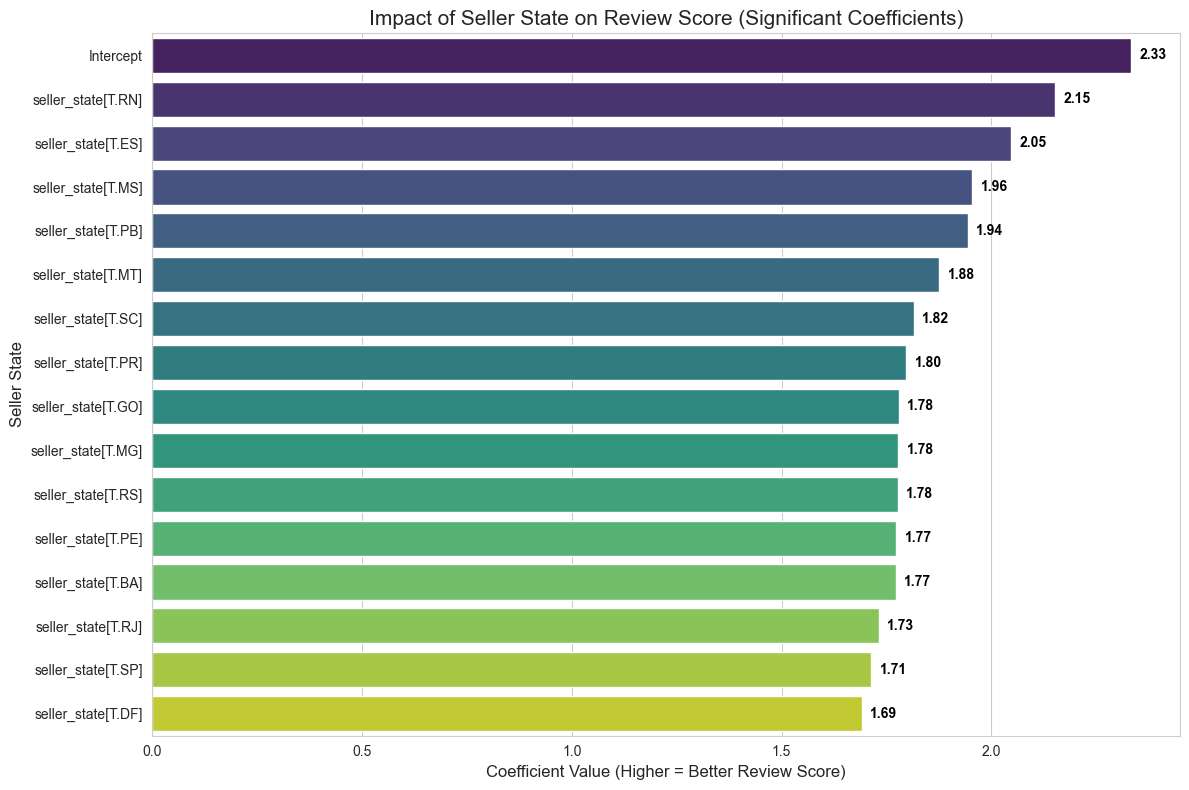

In [63]:
df_plot = significant_states.sort_values(by='coef', ascending=False)

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

plot = sns.barplot(
    data=df_plot,
    x='coef',
    y='variable',
    hue='variable',
    palette='viridis',
    legend=False
)

plt.title('Impact of Seller State on Review Score (Significant Coefficients)', fontsize=15)
plt.xlabel('Coefficient Value (Higher = Better Review Score)', fontsize=12)
plt.ylabel('Seller State', fontsize=12)

for i, v in enumerate(df_plot['coef']):
    plot.text(v + 0.02, i, f'{v:.2f}', color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

☝️ Bazı eyaletlerin ortalama olarak diğerlerinden _anlamlı_ biçimde daha iyi değerlendirmelere sahip olduğu görülebilir.

🤔 Bu, daha düşük `quantity_per_order`, daha kısa `wait_time` veya `delay_to_carrier`'dan mı kaynaklanıyor? Yoksa elimizde olmayan başka faktörlerden mi?

❓ **`seller_state` etkisini diğerlerinden izole etmeye çalışın: OLS modelinize sürekli (continuous) diğer özellikleri ekleyin; `seller_state` artık istatistiksel olarak anlamlı olmayana kadar devam edin!**

In [64]:
formula_isolated = 'review_score ~ seller_state + wait_time + delay_to_carrier + quantity_per_order'

model_isolated = smf.ols(formula=formula_isolated, data=sellers_standardized).fit()

In [65]:
from olist.utils import return_significative_coef
significant_isolated = return_significative_coef(model_isolated)

print("Lojistik Kontrolü Sonrası Anlamlı Eyaletler:")
print(significant_isolated)

Lojistik Kontrolü Sonrası Anlamlı Eyaletler:
              variable       p_value      coef
0            Intercept  6.750513e-07  3.724952
24  quantity_per_order  4.109493e-07 -0.069532
23    delay_to_carrier  7.116973e-13 -0.111730
22           wait_time  4.859417e-70 -0.284199


Eyaletler arası memnuniyet farklarını gidermek için özel bir 'bölgesel eğitim' programına gerek yok. Tek yapmamız gereken, lojistik olarak zayıf kalan eyaletlerdeki teslimat sürelerini (wait_time) iyileştirmek. Operasyonel hızı standartlaştırdığımızda, Brezilya'nın her yerinde müşteri memnuniyeti eşitlenecektir.

☝️ Analize `wait_time` ekledikten sonra, 22 adet `is_seller_state_xx` dummy değişkeninin hiçbirinin istatistiksel olarak anlamlı olmadığı görüldü:

Küçük veri setimiz göz önüne alındığında (çoğu eyalette çok az sayıda satıcı var):
- "Bazı eyaletlerin, `wait_time` dışındaki nedenlerle doğal olarak diğerlerinden daha iyi olduğu" sonucuna _varamayız_.
- Başka bir deyişle, "`seller_state`'in `wait_time` dışında `review_score` üzerinde etkisi yoktur" hipotezini reddedemeyiz.

🏁 Tebrikler!

💾 Commit ve push yapın:
- `sellers.ipynb` not defterinizi
- ayrıca `seller.py` dosyanızı